In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.ticker import FuncFormatter

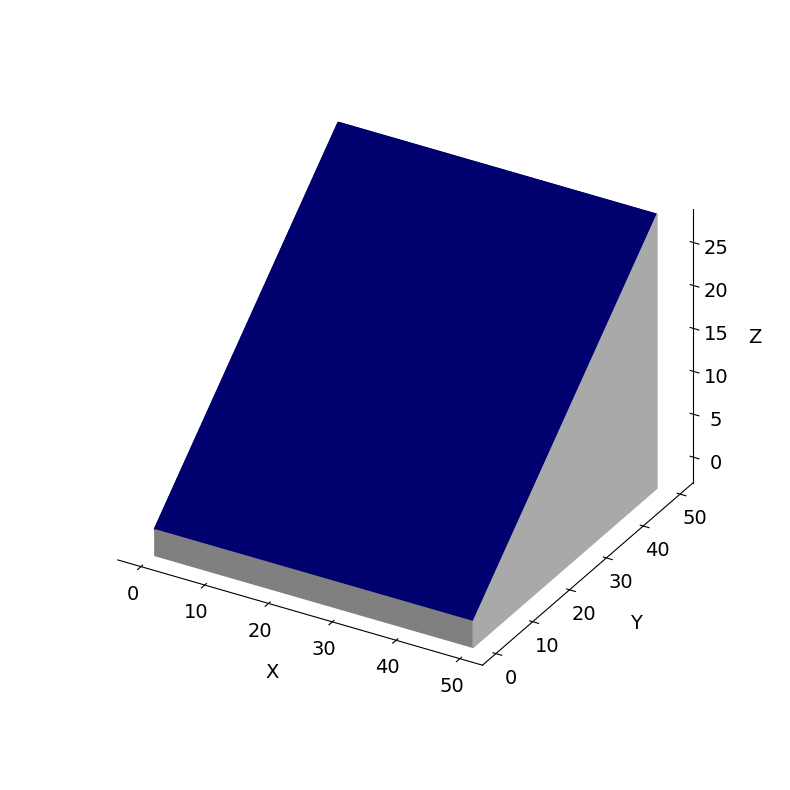

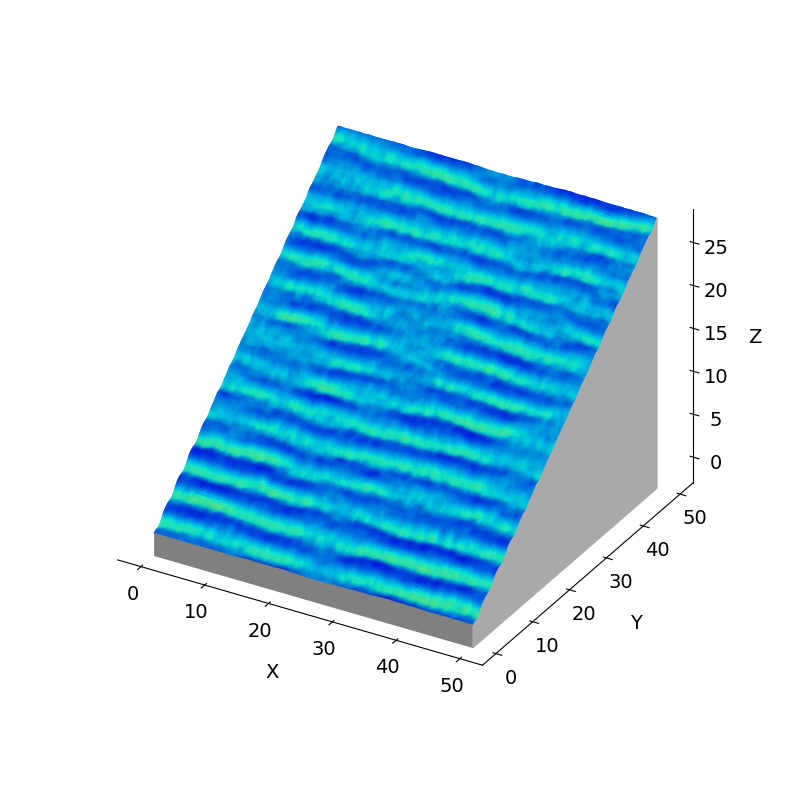

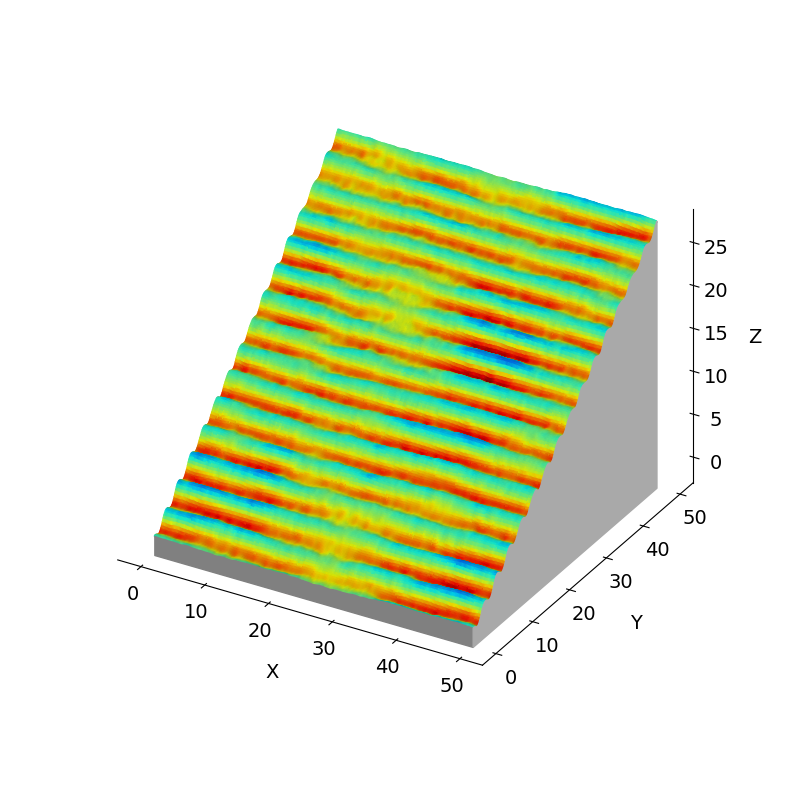

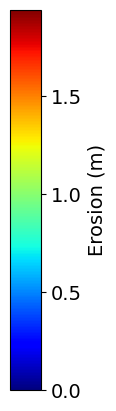

In [ ]:
plt.rcParams.update({'font.size': 14})

folder = 'fig05'
length = len([name for name in os.listdir(folder) if name.startswith('frame')])

# Load the initial and final maps to determine bounds
elevation_map = np.load(folder + '/frame0.npy')
final_map = np.load(folder + f'/frame{350}.npy')

z_min = elevation_map.min() - 30  # Adjust to control the depth

# Determine the z-bounds for plotting
max_height = np.max(elevation_map)
min_height = z_min

# Determine the color bounds for the colormap
difference = elevation_map - final_map
max_erosion = np.max(difference)
min_erosion = 0
norm = plt.Normalize(min_erosion, max_erosion)

# Scale tick labels by 10
def scale_ticks(val, pos):
    return f'{int(val / 10)}'

# Create a grid for the surface plot
x = np.arange(elevation_map.shape[0])
y = np.arange(elevation_map.shape[1])
x, y = np.meshgrid(x, y)

frame = [0, 175, 350]

for i in range(len(frame)): 
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d', proj_type='ortho')

    current_map = np.load(folder + f'/frame{frame[i]}.npy')
    difference = elevation_map - current_map
    colors = plt.cm.jet(norm(difference))
    ax.plot_surface(x, y, current_map, facecolors=colors, cstride=2, rstride=2)

    # Define and add the side "walls" using Poly3DCollection
    verts_bottom = [
        # Bottom edge wall
        [(x[0, i], y[0, i], current_map[0, i]) for i in range(x.shape[1])] +
        [(x[0, i], y[0, i], z_min) for i in range(x.shape[1])][::-1],
    ]
    verts_right = [
        # Right edge wall
        [(x[i, -1], y[i, -1], current_map[i, -1]) for i in range(x.shape[0])] +
        [(x[i, -1], y[i, -1], z_min) for i in range(x.shape[0])][::-1]
    ]
    # Add walls as polygons with Poly3DCollection
    poly_bottom = Poly3DCollection(verts_bottom, color='gray', alpha=1)
    ax.add_collection3d(poly_bottom)
    poly_right = Poly3DCollection(verts_right, color='darkgray', alpha=1)
    ax.add_collection3d(poly_right)

    ax.set_zlim(min_height, max_height)

    ax.xaxis.set_major_formatter(FuncFormatter(scale_ticks))
    ax.yaxis.set_major_formatter(FuncFormatter(scale_ticks))
    ax.zaxis.set_major_formatter(FuncFormatter(scale_ticks))

    ax.set_xlabel('X', labelpad=17)
    ax.set_ylabel('Y', labelpad=17)
    ax.set_zlabel('Z', labelpad=10)

    ax.grid(False)
    ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

    ax.set_box_aspect(None, zoom=0.85)
    
    #plt.savefig(f'Figures/VideoFrame{i}.png', transparent=True)
    plt.show()

# Let's plot the colorbar as a separate figure
# Define the colormap and norm
cmap = plt.cm.jet  # Replace with your chosen colormap
norm = mpl.colors.Normalize(vmin=min_erosion, vmax=max_erosion)  # Assuming min_erosion and max_erosion are defined

# Create a standalone colorbar figure
fig, ax = plt.subplots(figsize=(0.4,10))
fig.subplots_adjust(bottom=0.5)  # Adjust layout for better placement

# Create a colorbar
labels = np.array([0, 5, 10, 15])
cbar = mpl.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm, ticks=labels, orientation='vertical')
cbar.ax.set_yticklabels(["0.0", "0.5", "1.0", "1.5"])
cbar.set_label('Erosion (m)')

# Show the colorbar
#plt.savefig('Figures/Fig4colorbar.png', transparent=True, bbox_inches='tight')
plt.show()
